<a href="https://colab.research.google.com/github/wodud19492/-2025-2-EEE4178-Hands-On/blob/main/Day6_2025_Attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ref. https://udlbook.github.io/udlbook/ Notebook 12.1 & 12.2

# **General Attention (Cross Attention)**

Let's implement **General Attention** (often called **Cross-Attention**). In this mechanism:
* The **Queries** come from a target sequence $\mathbf{X}_q$ (e.g., decoder input).
* The **Keys** and **Values** come from a source sequence $\mathbf{X}_{kv}$ (e.g., encoder output).

This allows the model to relate information from two different sequences. Note that the number of inputs in the query sequence ($N_q$) can be different from the number of inputs in the key/value sequence ($N_{kv}$).

In [113]:
import numpy as np
import matplotlib.pyplot as plt

In [114]:
# 동일한 난수를 얻기 위해 시드 설정
np.random.seed(3)

# 차원 정의
D = 4

# Query(타겟 시퀀스) 입력 수
N_q = 3
# Key/Value(소스 시퀀스) 입력 수 -> N_q와 다를 수 있음
N_kv = 5

# 무작위 입력 데이터셋 생성
X_q = np.random.normal(size=(D, N_q))   # Query 입력
X_kv = np.random.normal(size=(D, N_kv)) # Key/Value 입력

omega_q = np.random.normal(size=(D,D))
omega_k = np.random.normal(size=(D,D))
omega_v = np.random.normal(size=(D,D))
beta_q = np.random.normal(size=(D,1))
beta_k = np.random.normal(size=(D,1))
beta_v = np.random.normal(size=(D,1))

print("Query 입력 X_q 형태:", X_q.shape)
print("Key/Value 입력 X_kv 형태:", X_kv.shape)


Query 입력 X_q 형태: (4, 3)
Key/Value 입력 X_kv 형태: (4, 5)


In [115]:

# 각 열에서 독립적으로 작동하는 softmax 연산 정의
def softmax_cols(data_in):
  # 모든 값에 지수 함수 적용
  exp_values = np.exp(data_in) ;
  # 열별로 합산
  denom = np.sum(exp_values, axis = 0);
  # 분모를 N개 행으로 복제
  denom = np.matmul(np.ones((data_in.shape[0],1)), denom[np.newaxis,:])
  # softmax 계산
  softmax_out = exp_values / denom
  # 결과 반환
  return softmax_out


In [116]:
# General (Cross) Attention 함수 정의
def general_attention(X_q, X_kv, omega_v, omega_q, omega_k, beta_v, beta_q, beta_k):

  # TODO -- 이 함수를 작성하세요
  # 1. X_q에서 Query 계산
  # 2. X_kv에서 Key와 Value 계산
  # 3. 내적 계산
  # 4. 내적 값 스케일링
  # 5. softmax를 적용하여 Attention 계산
  # 6. Attention으로 Value 가중치 부여

  # 1. Query, Key, Value 계산
  # Query는 X_q에서 나옴
  Q = np.matmul(omega_q, X_q) + beta_q
  # Key와 Value는 X_kv에서 나옴
  K = np.matmul(omega_k, X_kv) + beta_k
  V = np.matmul(omega_v, X_kv) + beta_v

  # 2. 내적 계산
  # 차원: (D x N_q)^T @ (D x N_kv) -> (N_q x D) @ (D x N_kv) -> (N_q x N_kv)
  # 하지만 우리는 각 Query(열)에 대한 Attention 맵을 원하므로, 보통 K^T @ Q를 계산합니다.
  # 또는 이 노트북의 규칙(Attention에 의해 가중된 Value)에 따르면:
  # 우리는 (N_kv, N_q) 크기의 Attention 스코어가 필요합니다. 그래야 각 Query 열에 대해 N_kv개의 Key에 대해 합산할 수 있습니다.
  # 이전 셀의 규칙을 확인해 봅시다:
  # Self-Attention: exp(K^T * q) -> 열별로 Softmax.
  # 여기: K는 D x N_kv, Q는 D x N_q.
  # 내적 = K.T @ Q 결과는 (N_kv x N_q)
  dot_products = np.matmul(K.T, Q)

  # 3. 내적 값 스케일링
  scaled_dot_products = dot_products / np.sqrt(D)

  # 4. Softmax를 적용하여 Attention 계산
  # softmax_cols는 열별로 작동하므로, 각 Query(열)에 대해 Key(행)에 대한 가중치 합계가 1이 됩니다.
  attention_weights = softmax_cols(scaled_dot_products)

  # 5. Attention으로 Value 가중치 부여
  # V는 (D x N_kv), attention_weights는 (N_kv x N_q)
  # 결과 X_prime은 (D x N_q)
  X_prime = np.matmul(V, attention_weights)

  return X_prime


In [117]:
# General Attention 메커니즘 실행
# 여기서는 단순화를 위해 이전에 정의된 동일한 무작위 가중치를 사용합니다.
# 하지만 실제로는 아키텍처에 따라 달라지거나 공유될 수 있습니다.

X_prime_gen = general_attention(X_q, X_kv, omega_v, omega_q, omega_k, beta_v, beta_q, beta_k)

# 결과 출력
print("출력 X_prime 형태:", X_prime_gen.shape) # (D, N_q)여야 합니다.
print("\n결과 X_prime:")
print(X_prime_gen)


출력 X_prime 형태: (4, 3)

결과 X_prime:
[[-3.874 -3.324 -3.067]
 [ 0.054 -3.226  0.744]
 [ 0.59  -2.874  0.474]
 [ 0.239 -0.521 -0.573]]


# **Self Attention**

This notebook builds a self-attention mechanism from scratch, as discussed in section 12.2 of the book.

Work through the cells below, running each cell in turn. In various places you will see the words "TODO". Follow the instructions at these places and make predictions about what is going to happen or write code to complete the functions.

Contact me at udlbookmail@gmail.com if you find any mistakes or have any suggestions.



The self-attention mechanism maps $N$ inputs $\mathbf{x}_{n}\in\mathbb{R}^{D}$ and returns $N$ outputs $\mathbf{x}'_{n}\in \mathbb{R}^{D}$.  



In [118]:
# Self-Attention을 위한 omega 및 beta 초기화
np.random.seed(3)

# 입력 수
N = 3
# 각 입력의 차원 수
D = 4
# 빈 리스트 생성
all_x = []
# 요소 x_n을 생성하고 리스트에 추가
for n in range(N):
  all_x.append(np.random.normal(size=(D,1)))
# 리스트 출력
print(all_x)


[array([[ 1.789],
       [ 0.437],
       [ 0.096],
       [-1.863]]), array([[-0.277],
       [-0.355],
       [-0.083],
       [-0.627]]), array([[-0.044],
       [-0.477],
       [-1.314],
       [ 0.885]])]


In [119]:
# Set seed so we get the same random numbers
np.random.seed(0)

# Choose random values for the parameters
omega_q = np.random.normal(size=(D,D))
omega_k = np.random.normal(size=(D,D))
omega_v = np.random.normal(size=(D,D))
beta_q = np.random.normal(size=(D,1))
beta_k = np.random.normal(size=(D,1))
beta_v = np.random.normal(size=(D,1))

We'll also need the weights and biases for the keys, queries, and values (equations 12.2 and 12.4)

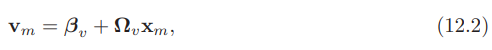
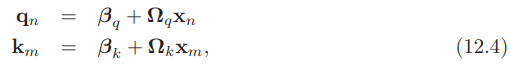

Now let's compute the queries, keys, and values for each input

In [120]:
# Query, Key, Value를 저장할 세 개의 리스트 생성
all_queries = []
all_keys = []
all_values = []
# 모든 입력에 대해
for x in all_x:
  # TODO -- Key, Query, Value를 계산합니다.
  # 이 세 줄을 교체하세요.
  query = np.matmul(omega_q, x) + beta_q
  key = np.matmul(omega_k, x) + beta_k
  value = np.matmul(omega_v, x) + beta_v

  all_queries.append(query)
  all_keys.append(key)
  all_values.append(value)


We'll need a softmax function (equation 12.5) -- here, it will take a list of arbitrary numbers and return a list where the elements are non-negative and sum to one

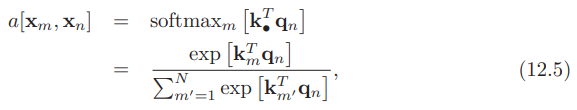

In [121]:
def softmax(items_in):

  # items_out의 요소들을 계산합니다.
  exp_values = np.exp(items_in)
  items_out = exp_values / np.sum(exp_values)

  return items_out ;

Now compute the self attention values:

In [122]:
# 출력을 위한 빈 리스트 생성
all_x_prime = []

# 각 출력에 대해
for n in range(N):
  # Query N과 모든 Key의 내적을 위한 리스트 생성
  all_km_qn = []
  # 내적 계산
  for key in all_keys:
    # TODO -- 적절한 내적을 계산합니다.
    # 이 줄을 교체하세요.
    dot_product = np.matmul(key.T, all_queries[n])

    # 내적 저장
    all_km_qn.append(dot_product)

  # 내적 계산
  attention = softmax(np.array(all_km_qn).flatten())
  # 결과 출력 (양수여야 하고 합이 1이어야 함)
  print("출력 ", n, "에 대한 Attention")
  print(attention)

  # TODO: Attention에 따라 모든 Value의 가중 합계를 계산합니다.
  # (방정식 12.3)
  # 이 줄을 교체하세요.
  x_prime = np.zeros((D,1))
  for m in range(N):
    x_prime += attention[m] * all_values[m]

  all_x_prime.append(x_prime)


# 올바른지 확인하기 위해 실제 값 출력
print("x_prime_0_calculated:", all_x_prime[0].transpose())
print("x_prime_0_true: [[ 0.94744244 -0.24348429 -0.91310441 -0.44522983]]")
print("x_prime_1_calculated:", all_x_prime[1].transpose())
print("x_prime_1_true: [[ 1.64201168 -0.08470004  4.02764044  2.18690791]]")
print("x_prime_2_calculated:", all_x_prime[2].transpose())
print("x_prime_2_true: [[ 1.61949281 -0.06641533  3.96863308  2.15858316]]")


출력  0 에 대한 Attention
[1.243e-13 9.983e-01 1.719e-03]
출력  1 에 대한 Attention
[2.795e-12 5.855e-03 9.941e-01]
출력  2 에 대한 Attention
[0.005 0.007 0.988]
x_prime_0_calculated: [[ 0.947 -0.243 -0.913 -0.445]]
x_prime_0_true: [[ 0.94744244 -0.24348429 -0.91310441 -0.44522983]]
x_prime_1_calculated: [[ 1.642 -0.085  4.028  2.187]]
x_prime_1_true: [[ 1.64201168 -0.08470004  4.02764044  2.18690791]]
x_prime_2_calculated: [[ 1.619 -0.066  3.969  2.159]]
x_prime_2_true: [[ 1.61949281 -0.06641533  3.96863308  2.15858316]]


Now let's compute the same thing, but using matrix calculations.  We'll store the $N$ inputs $\mathbf{x}_{n}\in\mathbb{R}^{D}$ in the columns of a $D\times N$ matrix, using equations 12.6 and 12.7/8.

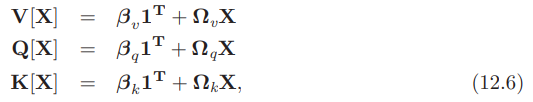

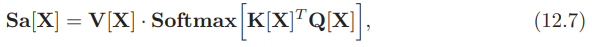

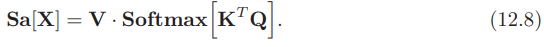

Note:  The book uses column vectors (for compatibility with the rest of the text), but in the wider literature it is more normal to store the inputs in the rows of a matrix;  in this case, the computation is the same, but all the matrices are transposed and the operations proceed in the reverse order.

In [123]:
# 이제 행렬 형태로 Self-Attention을 계산해 봅시다.
def self_attention(X,omega_v, omega_q, omega_k, beta_v, beta_q, beta_k):

  # 1. Query, Key, Value 계산
  Q = np.matmul(omega_q, X) + beta_q
  K = np.matmul(omega_k, X) + beta_k
  V = np.matmul(omega_v, X) + beta_v

  # 2. 내적 계산
  # (N x D) @ (D x N) -> (N x N)
  dot_products = np.matmul(K.T, Q)

  # 3. Attention을 계산하기 위해 softmax 적용
  attention_weights = softmax_cols(dot_products)

  # 4. Attention에 따라 Value를 가중치 부여
  # (D x N) @ (N x N) -> (D x N)
  X_prime = np.matmul(V, attention_weights)

  return X_prime

In [124]:
# 데이터를 행렬로 복사
X = np.zeros((D, N))
X[:,0] = np.squeeze(all_x[0])
X[:,1] = np.squeeze(all_x[1])
X[:,2] = np.squeeze(all_x[2])

# Self-Attention 메커니즘 실행
X_prime = self_attention(X,omega_v, omega_q, omega_k, beta_v, beta_q, beta_k)

# 결과 출력
print(X_prime)


[[ 0.947  1.642  1.619]
 [-0.243 -0.085 -0.066]
 [-0.913  4.028  3.969]
 [-0.445  2.187  2.159]]


If you did this correctly, the values should be the same as above.

TODO:  

Print out the attention matrix
You will see that the values are quite extreme (one is very close to one and the others are very close to zero.  Now we'll fix this problem by using scaled dot-product attention.

In [125]:
# 이제 행렬 형태로 Self-Attention을 계산해 봅시다.
def scaled_dot_product_self_attention(X,omega_v, omega_q, omega_k, beta_v, beta_q, beta_k):

  # 1. Query, Key, Value 계산
  Q = np.matmul(omega_q, X) + beta_q
  K = np.matmul(omega_k, X) + beta_k
  V = np.matmul(omega_v, X) + beta_v

  # 2. 내적 계산
  dot_products = np.matmul(K.T, Q)

  # 3. 방정식 12.9와 같이 내적 값 스케일링
  scaled_dot_products = dot_products / np.sqrt(D)

  # 4. Attention을 계산하기 위해 softmax 적용
  attention_weights = softmax_cols(scaled_dot_products)

  # 5. Attention에 따라 Value를 가중치 부여
  X_prime = np.matmul(V, attention_weights)

  return X_prime

In [126]:
# Self-Attention 메커니즘 실행
X_prime = scaled_dot_product_self_attention(X,omega_v, omega_q, omega_k, beta_v, beta_q, beta_k)

# 결과 출력
print(X_prime)


[[ 0.974  1.596  1.326]
 [-0.237 -0.095  0.131]
 [-0.723  3.702  3.024]
 [-0.344  2.013  1.69 ]]


TODO -- Investigate whether the self-attention mechanism is covariant with respect to permutation.
If it is, when we permute the columns of the input matrix $\mathbf{X}$, the columns of the output matrix $\mathbf{X}'$ will also be permuted.


# **Multihead Self-Attention**

This notebook builds a multihead self-attention mechanism as in figure 12.6

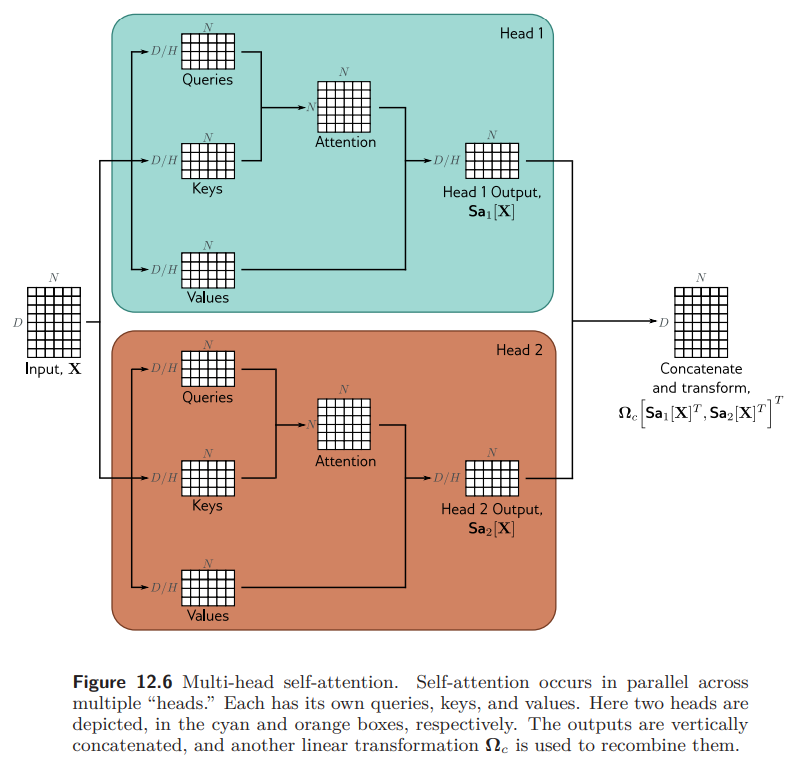


Work through the cells below, running each cell in turn. In various places you will see the words "TODO". Follow the instructions at these places and make predictions about what is going to happen or write code to complete the functions.

Contact me at udlbookmail@gmail.com if you find any mistakes or have any suggestions.



The multihead self-attention mechanism maps $N$ inputs $\mathbf{x}_{n}\in\mathbb{R}^{D}$ and returns $N$ outputs $\mathbf{x}'_{n}\in \mathbb{R}^{D}$.  



In [127]:
# 동일한 난수를 얻기 위해 시드 설정
np.random.seed(3)
# 입력 수
N = 6
# 각 입력의 차원 수
D = 8
# 빈 리스트 생성
X = np.random.normal(size=(D,N))
# X 출력
print(X)


[[ 1.789  0.437  0.096 -1.863 -0.277 -0.355]
 [-0.083 -0.627 -0.044 -0.477 -1.314  0.885]
 [ 0.881  1.71   0.05  -0.405 -0.545 -1.546]
 [ 0.982 -1.101 -1.185 -0.206  1.486  0.237]
 [-1.024 -0.713  0.625 -0.161 -0.769 -0.23 ]
 [ 0.745  1.976 -1.244 -0.626 -0.804 -2.419]
 [-0.924 -1.024  1.124 -0.132 -1.623  0.647]
 [-0.356 -1.743 -0.597 -0.589 -0.874  0.03 ]]


We'll use two heads.  We'll need the weights and biases for the keys, queries, and values (equations 12.2 and 12.4).  We'll use two heads, and (as in the figure), we'll make the queries keys and values of size D/H

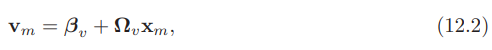
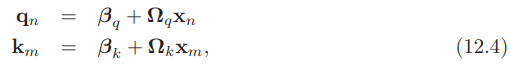

In [128]:
# 헤드 수
H = 2
# QDV 차원
H_D = int(D/H)

# 동일한 난수를 얻기 위해 시드 설정
np.random.seed(0)

# 첫 번째 헤드의 파라미터에 대한 난수 값 선택
omega_q1 = np.random.normal(size=(H_D,D))
omega_k1 = np.random.normal(size=(H_D,D))
omega_v1 = np.random.normal(size=(H_D,D))
beta_q1 = np.random.normal(size=(H_D,1))
beta_k1 = np.random.normal(size=(H_D,1))
beta_v1 = np.random.normal(size=(H_D,1))

# 두 번째 헤드의 파라미터에 대한 난수 값 선택
omega_q2 = np.random.normal(size=(H_D,D))
omega_k2 = np.random.normal(size=(H_D,D))
omega_v2 = np.random.normal(size=(H_D,D))
beta_q2 = np.random.normal(size=(H_D,1))
beta_k2 = np.random.normal(size=(H_D,1))
beta_v2 = np.random.normal(size=(H_D,1))

# 파라미터에 대한 난수 값 선택
omega_c = np.random.normal(size=(D,D))


Now let's compute the multiscale self-attention

In [129]:
 # 이제 행렬 형태로 Self-Attention을 계산해 봅시다.
def multihead_scaled_self_attention(X,omega_v1, omega_q1, omega_k1, beta_v1, beta_q1, beta_k1, omega_v2, omega_q2, omega_k2, beta_v2, beta_q2, beta_k2, omega_c):

  # 1. Q1, K1, V1 계산
  Q1 = np.matmul(omega_q1, X) + beta_q1
  K1 = np.matmul(omega_k1, X) + beta_k1
  V1 = np.matmul(omega_v1, X) + beta_v1

  # 2. Q2, K2, V2 계산
  Q2 = np.matmul(omega_q2, X) + beta_q2
  K2 = np.matmul(omega_k2, X) + beta_k2
  V2 = np.matmul(omega_v2, X) + beta_v2

  # 3. Head 1 에 대한 scaled dot product
  scaled_dot_products1 = np.matmul(K1.T, Q1) / np.sqrt(H_D)

  # 4. Head 2 에 대한 scaled dot product
  scaled_dot_products2 = np.matmul(K2.T, Q2) / np.sqrt(H_D)

  # 5. Head 1 의 Attention weight 계산
  attention_weights1 = softmax_cols(scaled_dot_products1)

  # 6. Head 2 의 Attention weight 계산
  attention_weights2 = softmax_cols(scaled_dot_products2)

  # 7. Head 1의 결괏값
  X_prime1 = np.matmul(V1, attention_weights1)

  # 8. Head 2의 결괏값
  X_prime2 = np.matmul(V2, attention_weights2)

  # 9. 두 결괏값을 Concate
  X_concat = np.concatenate((X_prime1, X_prime2), axis=0)

  # 10. 최종 결괏값 계산
  X_prime = np.matmul(omega_c, X_concat)

  return X_prime

In [130]:
# Self-Attention 메커니즘 실행
X_prime = multihead_scaled_self_attention(X,omega_v1, omega_q1, omega_k1, beta_v1, beta_q1, beta_k1, omega_v2, omega_q2, omega_k2, beta_v2, beta_q2, beta_k2, omega_c)

# 결과 출력
np.set_printoptions(precision=3)
print("당신의 답변:")
print(X_prime)

print("정답:")
print("[[-21.207  -5.373 -20.933  -9.179 -11.319 -17.812]")
print(" [ -1.995   7.906 -10.516   3.452   9.863  -7.24 ]")
print(" [  5.479   1.115   9.244   0.453   5.656   7.089]")
print(" [ -7.413  -7.416   0.363  -5.573  -6.736  -0.848]")
print(" [-11.261  -9.937  -4.848  -8.915 -13.378  -5.761]")
print(" [  3.548  10.036  -2.244   1.604  12.113  -2.557]")
print(" [  4.888  -5.814   2.407   3.228  -4.232   3.71 ]")
print(" [  1.248  18.894  -6.409   3.224  19.717  -5.629]]")

# 답이 일치하지 않는다면, 스케일링을 올바르게 했는지, 스케일링 값이 올바른지 확인하세요.


당신의 답변:
[[-21.207  -5.373 -20.933  -9.179 -11.319 -17.812]
 [ -1.995   7.906 -10.516   3.452   9.863  -7.24 ]
 [  5.479   1.115   9.244   0.453   5.656   7.089]
 [ -7.413  -7.416   0.363  -5.573  -6.736  -0.848]
 [-11.261  -9.937  -4.848  -8.915 -13.378  -5.761]
 [  3.548  10.036  -2.244   1.604  12.113  -2.557]
 [  4.888  -5.814   2.407   3.228  -4.232   3.71 ]
 [  1.248  18.894  -6.409   3.224  19.717  -5.629]]
정답:
[[-21.207  -5.373 -20.933  -9.179 -11.319 -17.812]
 [ -1.995   7.906 -10.516   3.452   9.863  -7.24 ]
 [  5.479   1.115   9.244   0.453   5.656   7.089]
 [ -7.413  -7.416   0.363  -5.573  -6.736  -0.848]
 [-11.261  -9.937  -4.848  -8.915 -13.378  -5.761]
 [  3.548  10.036  -2.244   1.604  12.113  -2.557]
 [  4.888  -5.814   2.407   3.228  -4.232   3.71 ]
 [  1.248  18.894  -6.409   3.224  19.717  -5.629]]
